In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/utsadas108/traffic-forecast/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns.docx
/kaggle/input/datasets/utsadas108/traffic-forecast/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/train_aWnotuB.csv
/kaggle/input/datasets/utsadas108/traffic-forecast/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/datasets_8494_11879_test_BdBKkAj.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [5]:
sns.set_style("whitegrid")

In [6]:
train_path = "/kaggle/input/datasets/utsadas108/traffic-forecast/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/train_aWnotuB.csv"

test_path = "/kaggle/input/datasets/utsadas108/traffic-forecast/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/datasets_8494_11879_test_BdBKkAj.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [7]:
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [8]:
train.shape
test.shape

(11808, 3)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [19]:
train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime'] = pd.to_datetime(test['DateTime'])
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [20]:
train.isnull().sum()
train = train.fillna(method='ffill')

In [24]:
train['Year'] = train['DateTime'].dt.year
train['Month'] = train['DateTime'].dt.month
train['Day'] = train['DateTime'].dt.day
train['Hour'] = train['DateTime'].dt.hour
train['DayOfWeek'] = train['DateTime'].dt.dayofweek
train.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


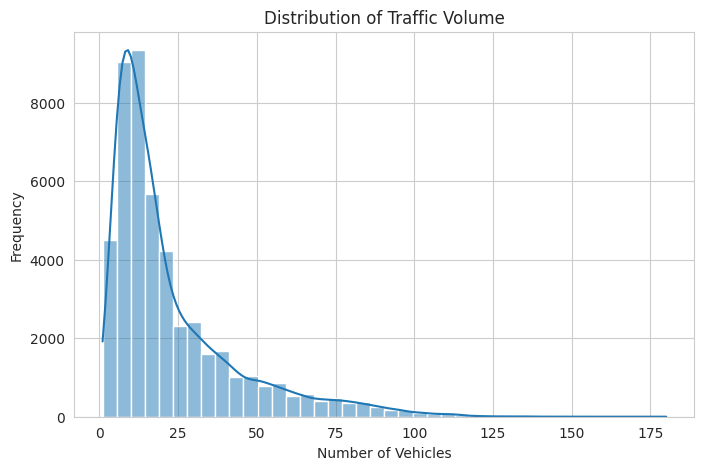

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(train['Vehicles'], bins=40, kde=True)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.show()

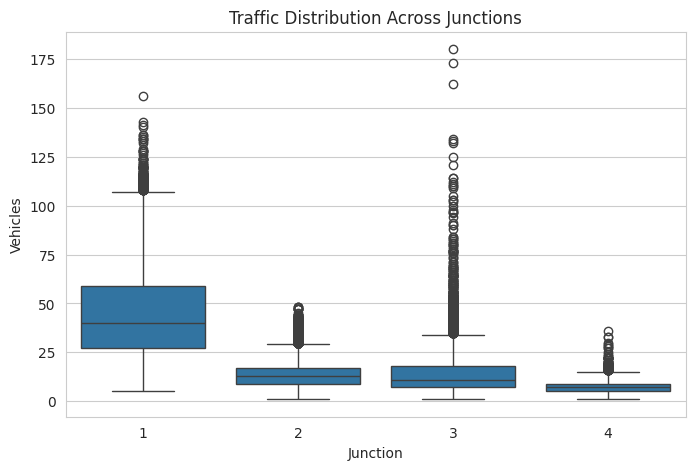

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Junction', y='Vehicles', data=train)

plt.title("Traffic Distribution Across Junctions")

plt.show()

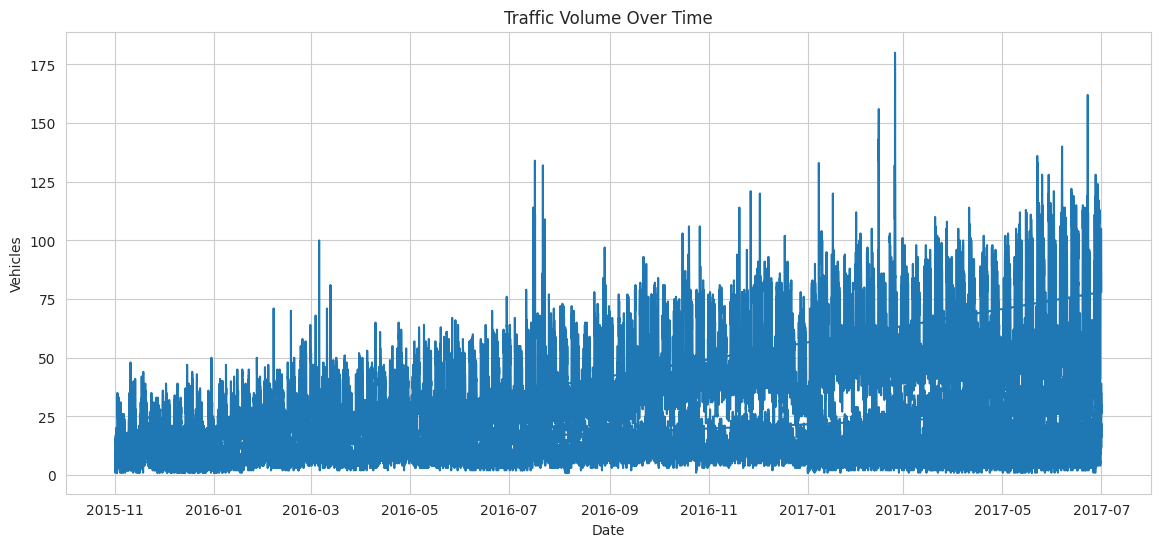

In [27]:
plt.figure(figsize=(14,6))

plt.plot(train['DateTime'], train['Vehicles'])

plt.title("Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Vehicles")

plt.show()

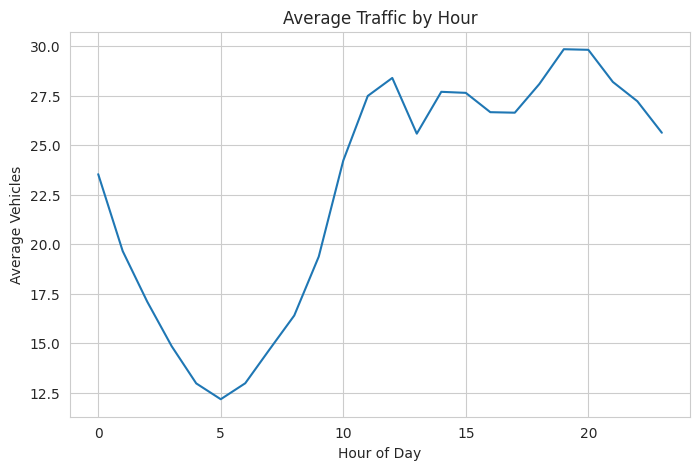

In [28]:
hourly_traffic = train.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize=(8,5))

hourly_traffic.plot()

plt.title("Average Traffic by Hour")

plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicles")

plt.show()

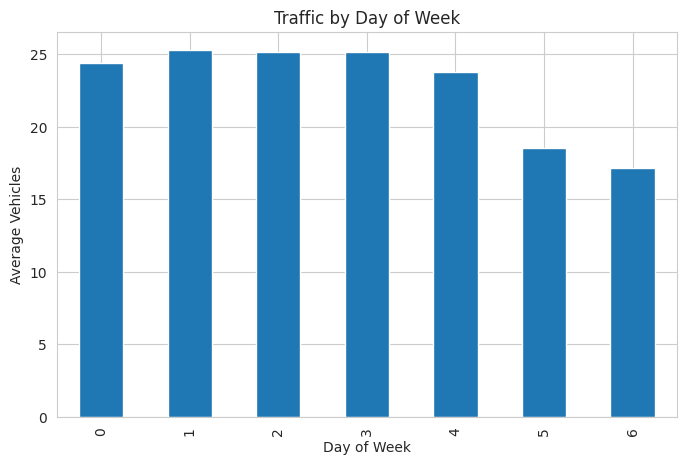

In [29]:
weekly_traffic = train.groupby('DayOfWeek')['Vehicles'].mean()

plt.figure(figsize=(8,5))

weekly_traffic.plot(kind='bar')

plt.title("Traffic by Day of Week")

plt.xlabel("Day of Week")
plt.ylabel("Average Vehicles")

plt.show()

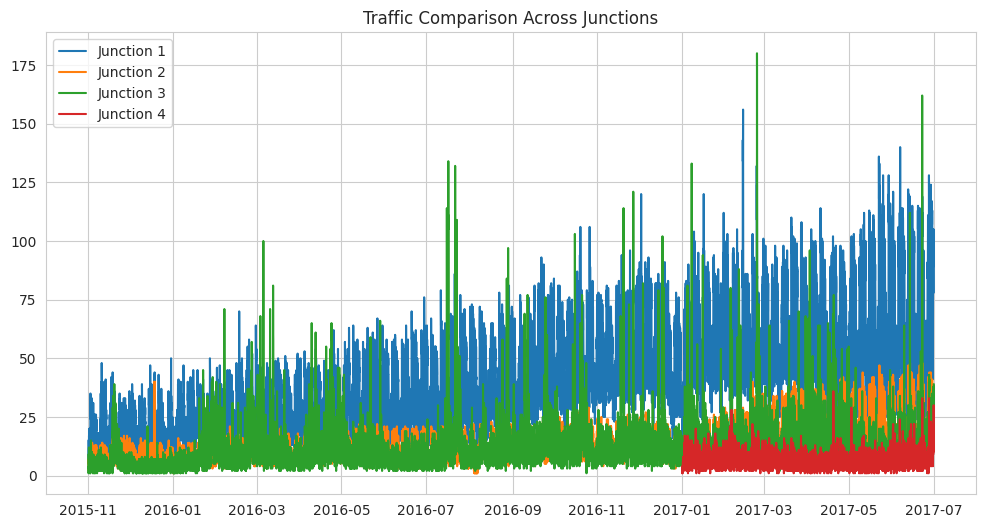

In [30]:
plt.figure(figsize=(12,6))

for j in train['Junction'].unique():
    
    subset = train[train['Junction'] == j]
    
    plt.plot(subset['DateTime'], subset['Vehicles'], label=f'Junction {j}')

plt.legend()

plt.title("Traffic Comparison Across Junctions")

plt.show()

In [31]:
junction1 = train[train['Junction'] == 1]
junction1 = junction1.set_index('DateTime')
junction1 = junction1.sort_index()

In [32]:
train_data = junction1['Vehicles'][:'2016-12-31']
test_data = junction1['Vehicles']['2017-01-01':]

In [33]:
print(train_data.shape)
print(test_data.shape)

(10248,)
(4344,)


In [35]:
model = ARIMA(train_data, order=(5,1,0))

model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               Vehicles   No. Observations:                10248
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -31455.110
Date:                Fri, 13 Mar 2026   AIC                          62922.220
Time:                        09:19:29   BIC                          62965.628
Sample:                    11-01-2015   HQIC                         62936.896
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1521      0.006     24.512      0.000       0.140       0.164
ar.L2          0.1015      0.008     12.744      0.000       0.086       0.117
ar.L3          0.0609      0.008      7.272      0.000       0.044       0.077
ar.L4          0.0449      0.010      4.525      0.000       0.025       0.064
ar.L5         -0.1011      0.011     -9.546      0.000      -0.122      -0.080
sigma2        27.1563      0.218    124.546      0.000      26.729      27.584
===================================================================================
Ljung-Box (L1) (Q):                   4.22   Jarque-Bera (JB):              7926.26
Prob(Q):                              0.04   Prob(JB):                         0.00
Heteroskedasticity (H):               2.07   Skew:                             0.49
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
forecast = model_fit.forecast(steps=len(test_data))
mae = mean_absolute_error(test_data, forecast)

rmse = np.sqrt(mean_squared_error(test_data, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 34.1761022727312
RMSE: 40.8687517324453


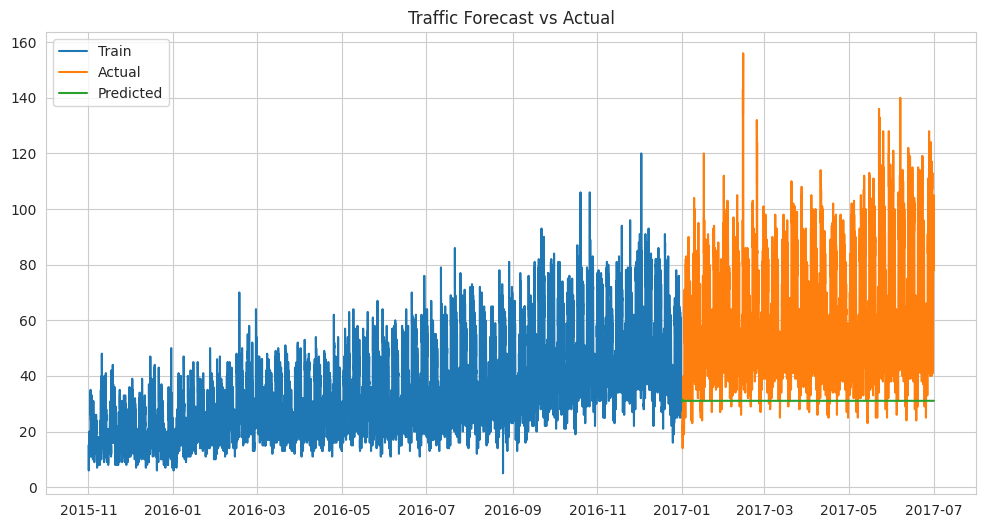

In [38]:
plt.figure(figsize=(12,6))

plt.plot(train_data.index, train_data, label="Train")

plt.plot(test_data.index, test_data, label="Actual")

plt.plot(test_data.index, forecast, label="Predicted")

plt.legend()

plt.title("Traffic Forecast vs Actual")

plt.show()

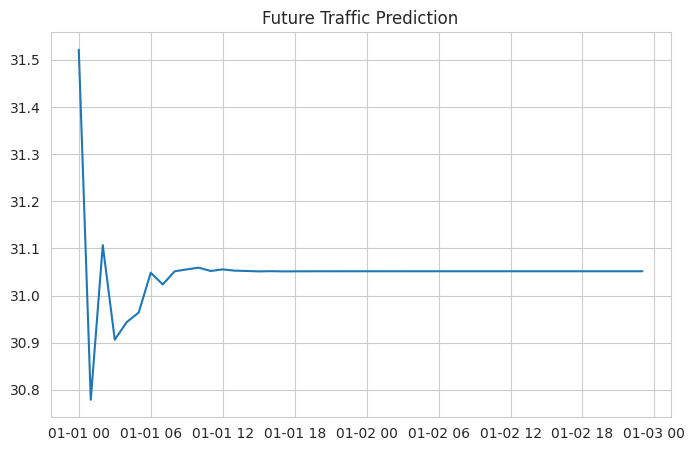

In [39]:
future_forecast = model_fit.forecast(steps=48)

plt.figure(figsize=(8,5))

plt.plot(future_forecast)

plt.title("Future Traffic Prediction")

plt.show()

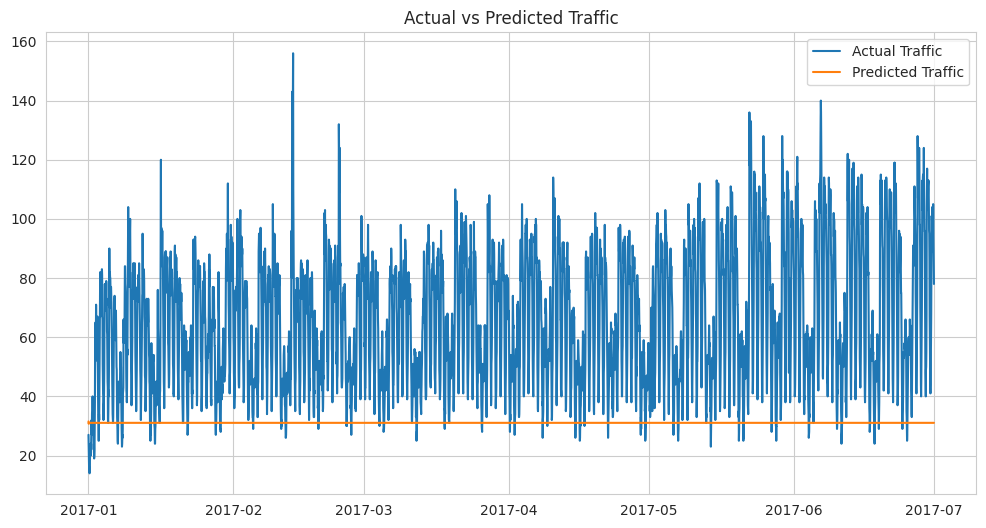

In [40]:
plt.figure(figsize=(12,6))

plt.plot(test_data.index, test_data, label="Actual Traffic")
plt.plot(test_data.index, forecast, label="Predicted Traffic")

plt.legend()
plt.title("Actual vs Predicted Traffic")

plt.show()

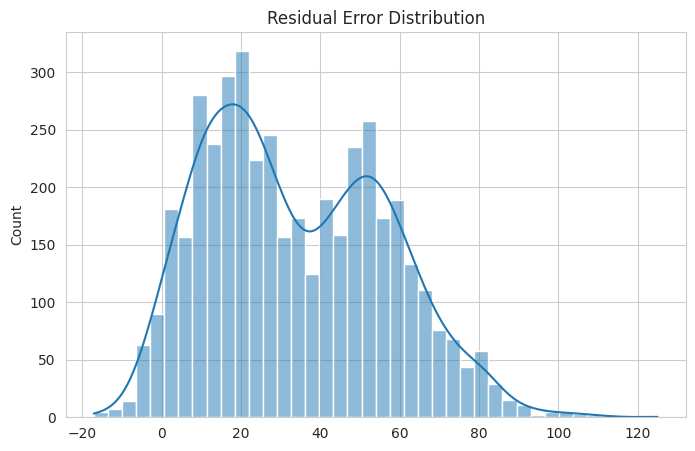

In [41]:
errors = test_data - forecast
plt.figure(figsize=(8,5))

sns.histplot(errors, bins=40, kde=True)

plt.title("Residual Error Distribution")

plt.show()

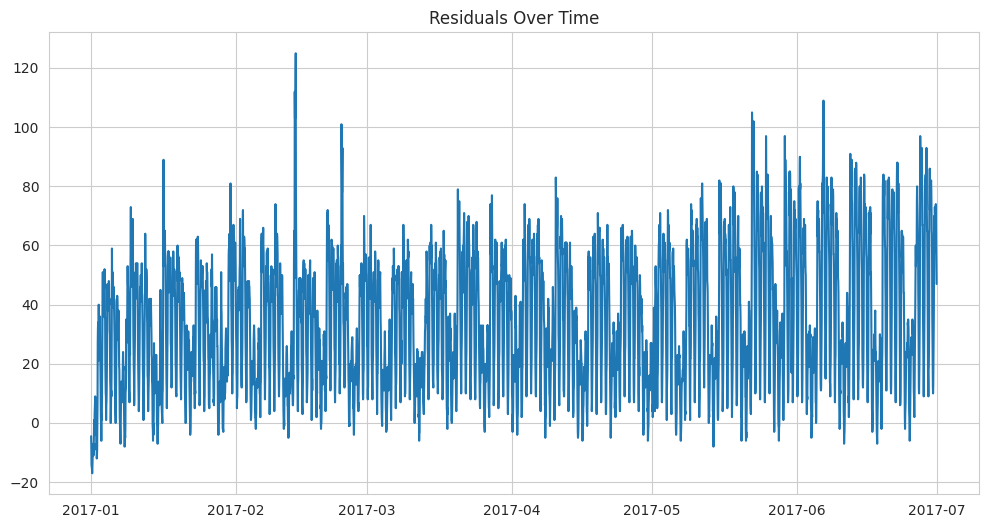

In [42]:
plt.figure(figsize=(12,6))

plt.plot(errors)

plt.title("Residuals Over Time")

plt.show()

In [43]:
test_data.sort_values(ascending=False).head(10)
forecast.sort_values(ascending=False).head(10)

2017-01-01 00:00:00    31.521278
2017-01-01 02:00:00    31.107137
2017-01-01 10:00:00    31.059250
2017-01-01 09:00:00    31.055597
2017-01-01 12:00:00    31.055590
2017-01-01 13:00:00    31.052962
2017-01-01 11:00:00    31.052260
2017-01-01 14:00:00    31.052235
2017-01-01 16:00:00    31.051869
2017-01-02 00:00:00    31.051667
Name: predicted_mean, dtype: float64

In [44]:
comparison = pd.DataFrame({
    "Actual": test_data,
    "Predicted": forecast
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Error
2017-01-01 00:00:00,27,31.521278,-4.521278
2017-01-01 01:00:00,23,30.779139,-7.779139
2017-01-01 02:00:00,17,31.107137,-14.107137
2017-01-01 03:00:00,16,30.906574,-14.906574
2017-01-01 04:00:00,16,30.943832,-14.943832
2017-01-01 05:00:00,14,30.964204,-16.964204
2017-01-01 06:00:00,14,31.048618,-17.048618
2017-01-01 07:00:00,18,31.023637,-13.023637
2017-01-01 08:00:00,20,31.051596,-11.051596
2017-01-01 09:00:00,22,31.055597,-9.055597
